In [8]:
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

selected_features = set([i[6:] for i in selected_features])
selected_features

{'L1',
 'Max',
 'Mean',
 'Min',
 'Ptp',
 'dif_L1',
 'dif_Max',
 'dif_Mean',
 'dif_Min',
 'dif_Ptp',
 'dif_dif_CumsumFinal',
 'dif_dif_L1',
 'dif_dif_Max',
 'dif_dif_Min',
 'dif_dif_Ptp'}

In [10]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from lightgbm import LGBMRegressor


# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 50
RANDOM_STATE = 42
NOISE_STD = 0.1
ALPHA = 0.7


# ==================== ДАННЫЕ ====================
features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap96.875.csv')

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

n_classes = len(np.unique(y))


# ==================== SPLIT ====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)


# ==================== SCALER ====================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==================== ПЕРЕСТАНОВКИ ====================
candidates = [
    [0, 1, 4, 5, 2, 3],
    [0, 1, 4, 2, 5, 3],
    [0, 1, 4, 2, 3, 5],
    [0, 1, 2, 3, 4, 5],
    [0, 1, 2, 4, 3, 5],
    [0, 1, 2, 4, 5, 3]
]


# ==================== PIPELINE ФУНКЦИИ ====================

def get_ordinal_features(X_train_s, X_test_s, y_train_m):
    models = []

    for k in range(1, n_classes):
        y_binary = (y_train_m >= k).astype(int)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        clf.fit(X_train_s, y_binary)
        models.append(clf)

    ord_train = np.mean([m.decision_function(X_train_s) for m in models], axis=0)
    ord_test = np.mean([m.decision_function(X_test_s) for m in models], axis=0)

    o_min, o_max = ord_train.min(), ord_train.max()

    ord_train_n = (ord_train - o_min) / (o_max - o_min)
    ord_test_n = (ord_test - o_min) / (o_max - o_min)

    return ord_train_n, ord_test_n


def get_regression_features(X_train, X_test, y_train_m):
    y_reg = y_train_m.astype(float) + np.random.normal(0, NOISE_STD, size=len(y_train_m))

    reg_model = LGBMRegressor(
        n_estimators=400,
        max_depth=10,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    reg_model.fit(X_train, y_reg)

    reg_train = reg_model.predict(X_train)
    reg_test = reg_model.predict(X_test)

    r_min, r_max = reg_train.min(), reg_train.max()

    reg_train_n = (reg_train - r_min) / (r_max - r_min)
    reg_test_n = (reg_test - r_min) / (r_max - r_min)

    return reg_train_n, reg_test_n


def compute_hybrid(mapping):
    y_train_m = np.array([mapping[v] for v in y_train])
    y_test_m = np.array([mapping[v] for v in y_test])

    ord_train_n, ord_test_n = get_ordinal_features(
        X_train_scaled, X_test_scaled, y_train_m
    )

    reg_train_n, reg_test_n = get_regression_features(
        X_train, X_test, y_train_m
    )

    risk_test = 100 * (ALPHA * ord_test_n + (1 - ALPHA) * reg_test_n)

    return risk_test, y_test_m, ord_test_n, reg_test_n


# ==================== ОЦЕНКА ПЕРЕСТАНОВКИ ====================
def evaluate_permutation(perm):

    mapping = {old: new for new, old in enumerate(perm)}

    risk_test, y_test_m, _, _ = compute_hybrid(mapping)

    spearman, _ = spearmanr(risk_test, y_test_m)

    means = [np.mean(risk_test[y_test_m == c]) for c in range(n_classes)]
    monotonic = all(means[i] < means[i+1] for i in range(n_classes - 1))

    return spearman, monotonic, mapping, risk_test, y_test_m


# ==================== ПОИСК ЛУЧШЕЙ ПЕРЕСТАНОВКИ ====================
best_spearman = -np.inf
best_mapping = None

for perm in candidates:
    spearman, monotonic, mapping, _, _ = evaluate_permutation(perm)

    if monotonic and spearman > best_spearman:
        best_spearman = spearman
        best_mapping = mapping

if best_mapping is None:
    raise ValueError("Нет монотонной перестановки")

print(f"Best Spearman: {best_spearman:.4f}")

inverse_mapping = {v: k for k, v in best_mapping.items()}
best_perm_list = [inverse_mapping[i] for i in range(n_classes)]
print("Лучшая перестановка:", best_perm_list)


# ==================== ФИНАЛЬНЫЙ ПРОГОН ====================
best_risk, best_y_test_m, ordinal_test_n, reg_test_n = compute_hybrid(best_mapping)


# ==================== СТАТИСТИКА ====================
print("\nСтатистика Risk:\n")

stats = []

for c in range(n_classes):
    data = best_risk[best_y_test_m == c]
    old_class = inverse_mapping[c]

    stats.append({
        'Новый класс': c,
        'Исходный класс': old_class,
        'Среднее': np.mean(data),
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"Класс {c} (исх.{old_class}): mean = {np.mean(data):.2f}%")

stats_df = pd.DataFrame(stats)
display(stats_df.style.hide(axis='index').format("{:.2f}"))


# ==================== KDE ====================
plt.figure(figsize=(12, 6))

for c in range(n_classes):
    data = best_risk[best_y_test_m == c]
    old_class = inverse_mapping[c]

    sns.kdeplot(data, label=f'{c} (old {old_class})', fill=True, alpha=0.3)

plt.title(f'Hybrid Risk Distribution\nSpearman: {best_spearman:.4f}')
plt.xlabel("Risk (%)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('APPLICATIONS/1.png', dpi=1000, bbox_inches='tight')
plt.show()


# ==================== BOXPLOT ====================
plt.figure(figsize=(12, 6))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(best_risk[best_y_test_m == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'New {new_class}\n(old {old_class})'] * sum(best_y_test_m == new_class)
    )

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

sns.boxplot(data=df_box, x='Class', y='Risk')

plt.title('Распределение риска для натурных данных по классам (boxplot)', fontsize=14)
plt.ylabel('Risk (%)', fontsize=12)
plt.xlabel('Класс', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('APPLICATIONS/2.png', dpi=1000, bbox_inches='tight')
plt.show()


# ==================== МОНОТОННОСТЬ ====================
plt.figure(figsize=(12, 6))

means = [np.mean(best_risk[best_y_test_m == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8)
plt.fill_between(
    new_classes,
    [np.percentile(best_risk[best_y_test_m == c], 25) for c in new_classes],
    [np.percentile(best_risk[best_y_test_m == c], 75) for c in new_classes],
    alpha=0.2,
    label='25-75 процентиль'
)

plt.xticks(new_classes, old_labels)
plt.xlabel('Новый класс (исходный класс)', fontsize=12)
plt.ylabel('Средний риск (%)', fontsize=12)
plt.title('Монотонность среднего риска для натурных данных', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('APPLICATIONS/3.png', dpi=1000, bbox_inches='tight')
plt.show()


# ========= UNCERTAINTY (разброс внутри класса) =========

plt.figure(figsize=(10, 6))

uncertainty = np.abs(ordinal_test_n - reg_test_n)

scatter = plt.scatter(
    best_risk,
    uncertainty,
    c=best_y_test_m,
    cmap='viridis',
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label='Class')

plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Uncertainty |Ordinal - Reg|", fontsize=12)
plt.title("Uncertainty vs Risk", fontsize=14)


plt.axhline(y=np.mean(uncertainty), 
            linestyle='--', 
            alpha=0.7, 
            linewidth=1,
            label='Mean uncertainty', 
            color="black")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('APPLICATIONS/4.png', dpi=1000, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

## Финальное обучение

1
1
Spearman correlation: 0.9738
p-value: 0.0000e+00


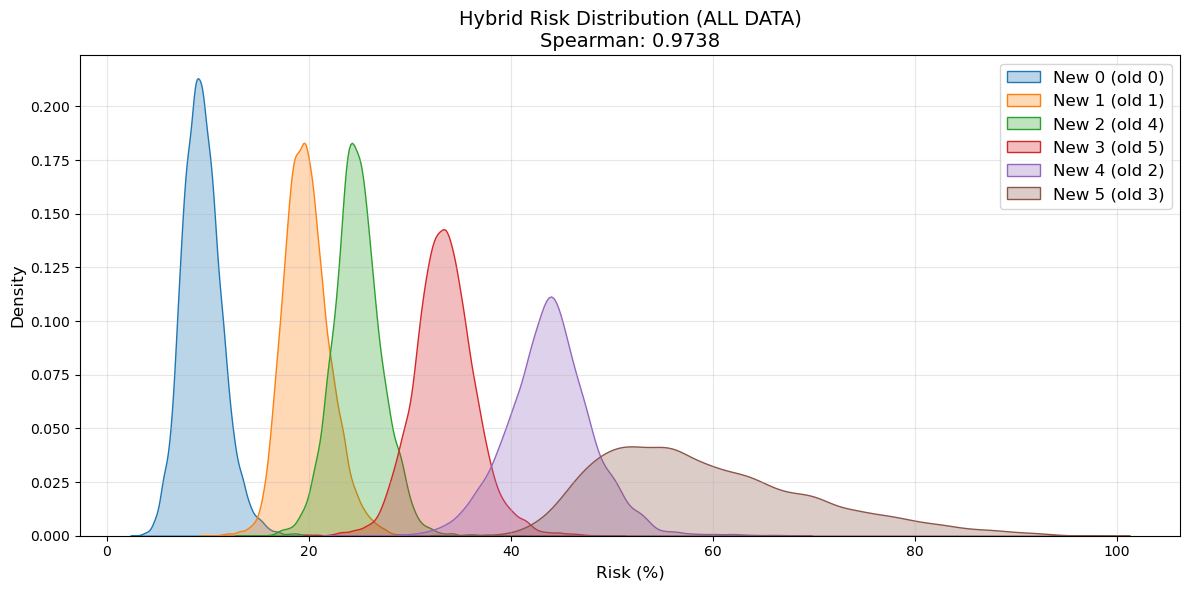

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMRegressor


# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 50
RANDOM_STATE = 42
NOISE_STD = 0.1
ALPHA = 0.7

# Фиксируем лучшую перестановку
fixed_perm = [0, 1, 4, 5, 2, 3]


# ==================== ДАННЫЕ ====================
features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap96.875.csv')

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

n_classes = len(np.unique(y))


# ==================== МАППИНГ ====================
mapping = {old: new for new, old in enumerate(fixed_perm)}
inverse_mapping = {v: k for k, v in mapping.items()}
y_mapped = np.array([mapping[v] for v in y])


# ==================== SCALER ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(1)

# =========================================================
# ORDINAL БЛОК 
# =========================================================
ordinal_models = []

for k in range(1, n_classes):
    y_binary = (y_mapped >= k).astype(int)

    clf = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    clf.fit(X_scaled, y_binary)
    ordinal_models.append(clf)

ordinal_all = np.mean(
    [m.decision_function(X_scaled) for m in ordinal_models],
    axis=0
)

o_min, o_max = ordinal_all.min(), ordinal_all.max()
ordinal_all_n = (ordinal_all - o_min) / (o_max - o_min)

print(1)

# =========================================================
# REGRESSION БЛОК 
# =========================================================
y_reg = y_mapped.astype(float) + np.random.normal(
    0, NOISE_STD, size=len(y_mapped)
)

reg_model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=-1
)

reg_model.fit(X, y_reg)

reg_all = reg_model.predict(X)

r_min, r_max = reg_all.min(), reg_all.max()
reg_all_n = (reg_all - r_min) / (r_max - r_min)


# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)


# =========================================================
# МЕТРИКИ
# =========================================================
spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")


# =========================================================
# СОХРАНЕНИЕ ПАЙПЛАЙНА
# =========================================================
with open("DATA/real_time/lhybrid_pipeline.pkl", "wb") as f:
    pickle.dump({
        "ordinal_models": ordinal_models,
        "reg_model": reg_model,
        "scaler": scaler,
        "mapping": mapping,
        "features": selected_features,
        "latent_min": o_min,
        "latent_max": o_max,
        "reg_min": r_min,
        "reg_max": r_max,
        "alpha": ALPHA
    }, f)


# =========================================================
# KDE 
# =========================================================
plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=1
    )

plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.title(
    f"Hybrid Risk Distribution (ALL DATA)\nSpearman: {spearman_corr:.4f}",
    fontsize=14
)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_all.png', dpi=1000, bbox_inches='tight')
plt.show()

Spearman correlation: 0.9738
p-value: 0.0000e+00

Статистика Latent Risk по классам:

  Класс 0: средний риск = 9.46%
  Класс 1: средний риск = 19.80%
  Класс 2: средний риск = 24.81%
  Класс 3: средний риск = 33.43%
  Класс 4: средний риск = 43.87%
  Класс 5: средний риск = 59.30%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максимум
0,0,9.46,2.02,9.31,8.07,10.63,3.17,21.41
1,1,19.80,2.32,19.62,18.22,21.17,9.97,33.06
2,4,24.81,2.46,24.69,23.28,26.24,13.68,40.51
3,5,33.43,3.09,33.34,31.49,35.24,20.68,50.05
4,2,43.87,4.34,43.83,41.26,46.34,23.11,68.06
5,3,59.30,10.34,57.35,51.37,65.61,36.24,97.01


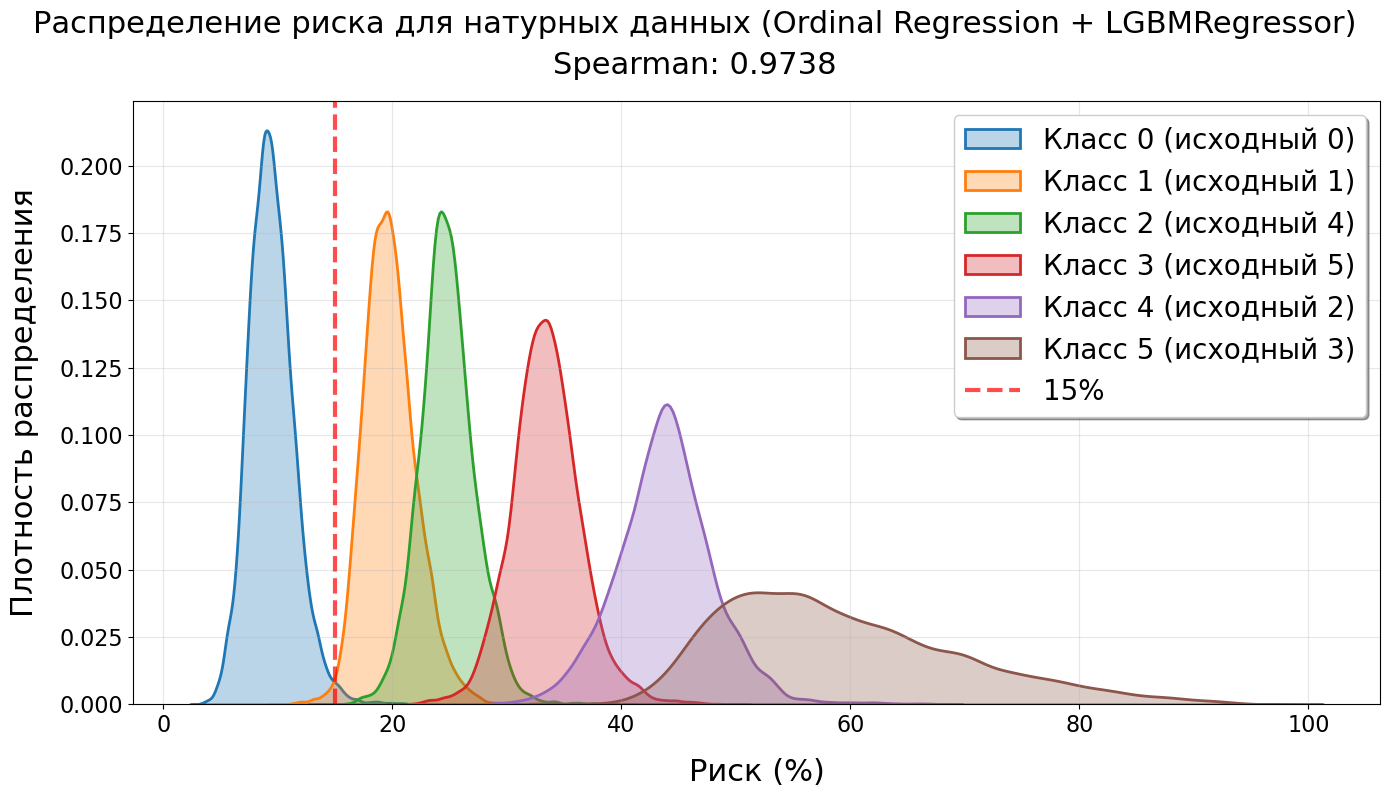

Класс 0: 1.16% значений выше 15%
Класс 0: 1.16% значений >= 15%


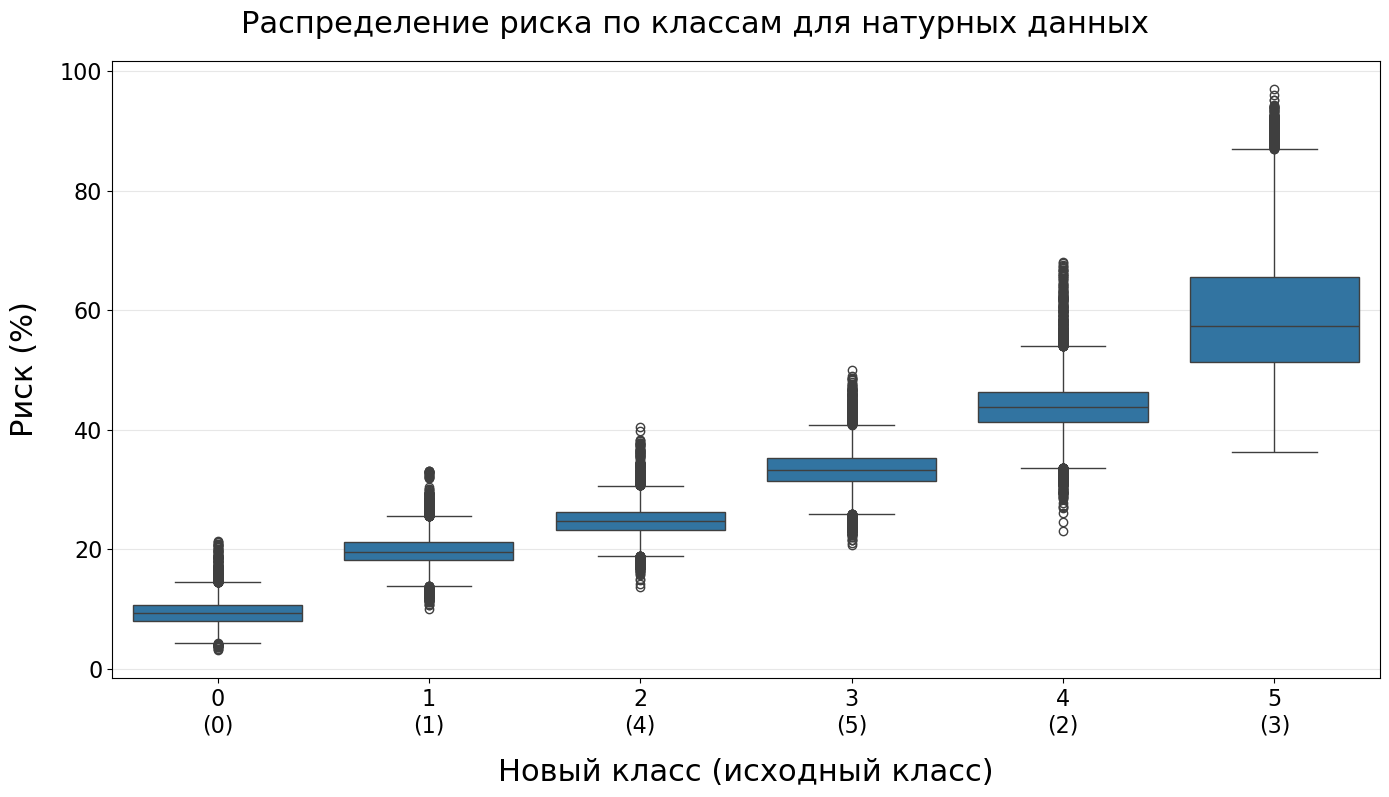

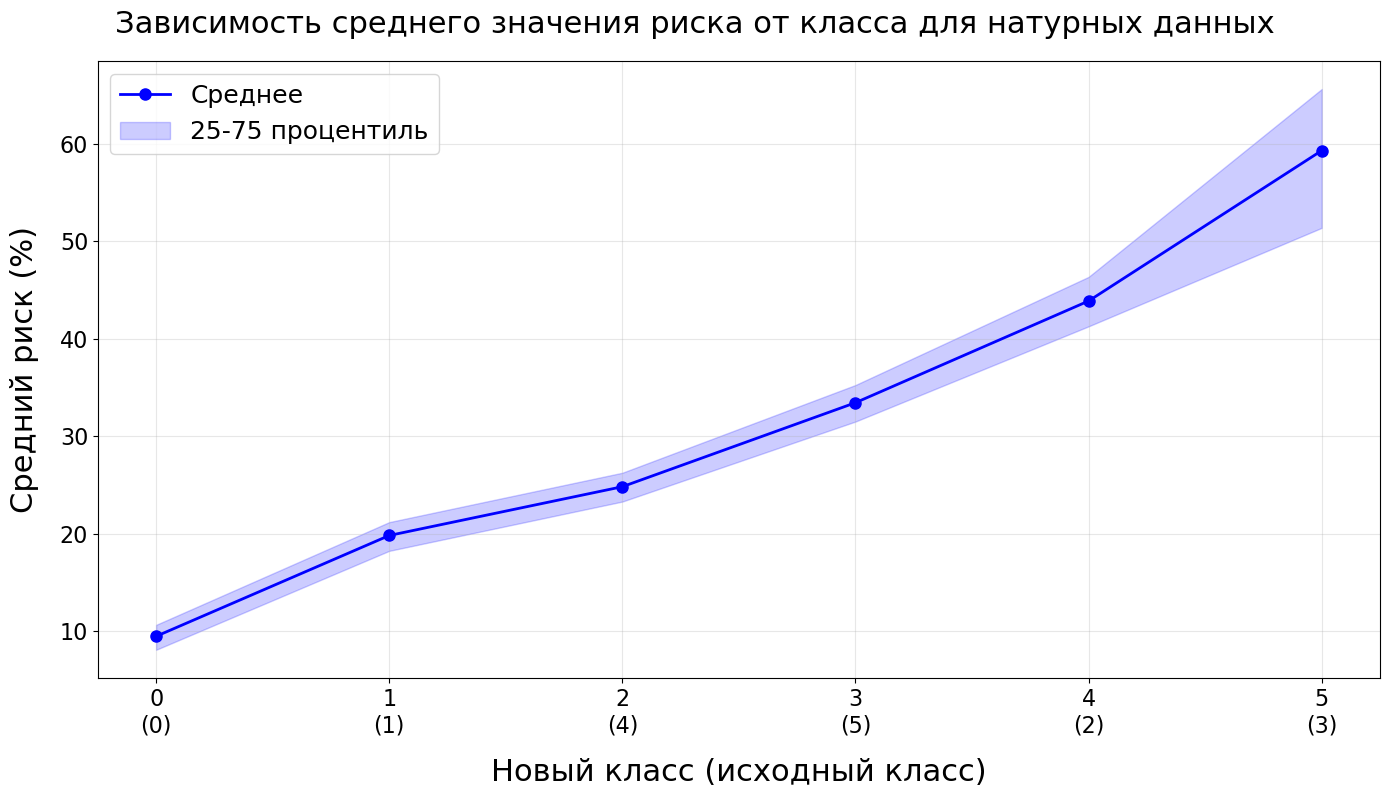

In [5]:
ALPHA = 0.7
# print(sns.axes_style())  # покажет текущие настройки
# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)

spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Класс {new_class}: средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максимум': '{:.2f}'
}))

# ==================== ГРАФИК 1: KDE распределение ====================

fig = plt.figure(figsize=(14, 8))
for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'Класс {new_class} (исходный {fixed_perm[new_class]})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Риск (%)", fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel("Плотность распределения", fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle(f"Распределение риска для натурных данных (Ordinal Regression + LGBMRegressor)\nSpearman: {spearman_corr:.4f}", fontsize=22, y=0.99, fontweight="medium", linespacing=1.5)
plt.axvline(x=15, color='red', linestyle='--', linewidth=3, alpha=0.7, label='15%')

plt.legend(loc='upper right', fontsize=20, frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig('APPLICATIONS/risk_distribution_xgb_with_line.png', dpi=600, bbox_inches='tight')
plt.show()

# Данные для класса 0
data_class0 = risk_all[y_mapped == 0]

# Процент значений > 15%
percent_above_15 = np.mean(data_class0 > 15) * 100

# Процент значений >= 15% (включительно)
percent_above_eq_15 = np.mean(data_class0 >= 15) * 100

print(f"Класс 0: {percent_above_15:.2f}% значений выше 15%")
print(f"Класс 0: {percent_above_eq_15:.2f}% значений >= 15%")

# ==================== ГРАФИК 2: Boxplot ====================

fig = plt.figure(figsize=(14, 8))

new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'{new_class}'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

sns.boxplot(data=df_box, x='Class', y='Risk')
plt.xticks(new_classes, old_labels)

fig.suptitle('Распределение риска по классам для натурных данных', fontsize=22, y=0.99, fontweight="medium")
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Новый класс (исходный класс)', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.3, axis='y')
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=600, bbox_inches='tight')
plt.show()


# ==================== ГРАФИК 3: Монотонность среднего риска ====================

fig = plt.figure(figsize=(14, 8))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

plt.xticks(new_classes, old_labels)
plt.xlabel('Новый класс (исходный класс)', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Средний риск (%)', fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle('Зависимость среднего значения риска от класса для натурных данных', fontsize=22, y=0.99, fontweight="medium")
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=18)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ========= ГРАФИК 4: UNCERTAINTY (разброс внутри класса) =========

# fig = plt.figure(figsize=(10, 6))

# uncertainty = np.abs(ordinal_test_n - reg_test_n)

# scatter = plt.scatter(
#     best_risk,
#     uncertainty,
#     c=best_y_test_m,
#     cmap='viridis',
#     alpha=0.5,
#     s=10
# )

# plt.colorbar(scatter, label='Class')

# plt.xlabel("Risk (%)", fontsize=12)
# plt.ylabel("Uncertainty |Ordinal - Reg|", fontsize=12)
# fig.suptitle("Uncertainty vs Risk", fontsize=14, y=0.99)


# plt.axhline(y=np.mean(uncertainty), 
#             linestyle='--', 
#             alpha=0.7, 
#             linewidth=1,
#             label='Mean uncertainty', 
#             color="black")

# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig('APPLICATIONS/4.png', dpi=1000, bbox_inches='tight')
# plt.show()

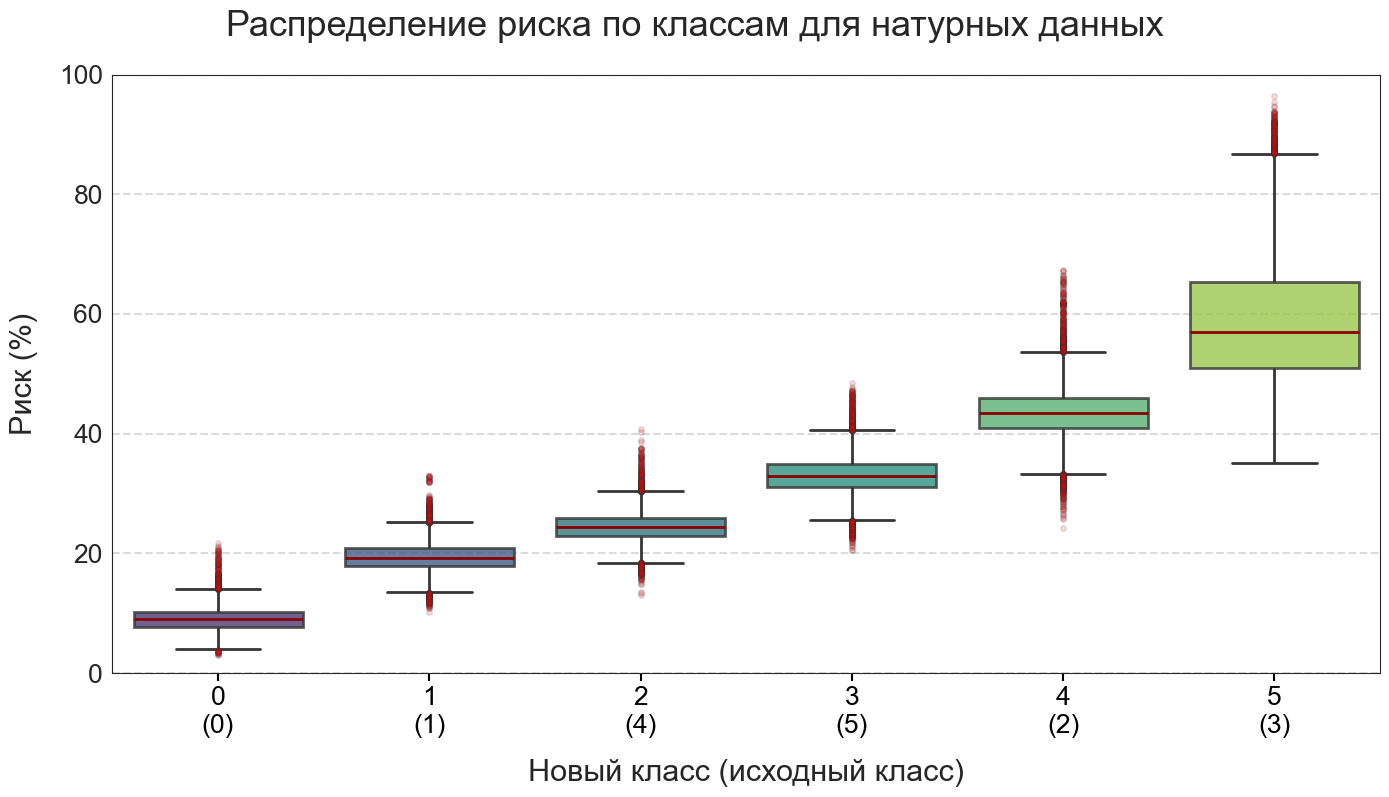

In [65]:
# ==================== ГРАФИК 2: Boxplot (улучшенный) ====================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Установка черного цвета для всего текста
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

# Настройка стиля seaborn для более современного вида
sns.set_style("white")
# sns.set_palette("husl")

# sns.set_style("darkgrid")
# sns.set_palette("deep")

fig = plt.figure(figsize=(14, 8))

plt.tick_params(
    axis='x',        # Обе оси
    which='both',       # Основные и второстепенные
    direction='out',    # Насечки наружу
    length=6,           # Длина насечки
    width=1.5,          # Толщина насечки
    colors='black',     # Цвет насечек
    labelsize=18,       # Размер подписей
    bottom=True,        # Нижние насечки
    left=True,          # Левые насечки
    top=False,          # Без верхних
    right=False         # Без правых
)

new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend([f'{new_class}'] * sum(y_mapped == new_class))

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

# Улучшенный boxplot с дополнительными элементами
boxplot = sns.boxplot(
    data=df_box, 
    x='Class', 
    y='Risk',
    palette='viridis',  # Более красивая цветовая схема
    linewidth=2,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4, 'alpha': 0.15},
    boxprops={'alpha': 0.8},
    whiskerprops={'linewidth': 2},
    capprops={'linewidth': 2},
    medianprops={'linewidth': 2, 'color': 'darkred'}
)

# Добавляем точки с джиттером для отображения всех значений


plt.xticks(new_classes, old_labels)

# Улучшенные метки и заголовок
fig.suptitle('Распределение риска по классам для натурных данных', fontsize=26, y=0.99, fontweight="medium")

plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Новый класс (исходный класс)', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.7, axis='y', linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=19)
plt.tick_params(axis='y', labelsize=19)
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 20))


plt.tight_layout()
plt.savefig('risk_boxplot_improved.png', dpi=600, bbox_inches='tight')
plt.show()

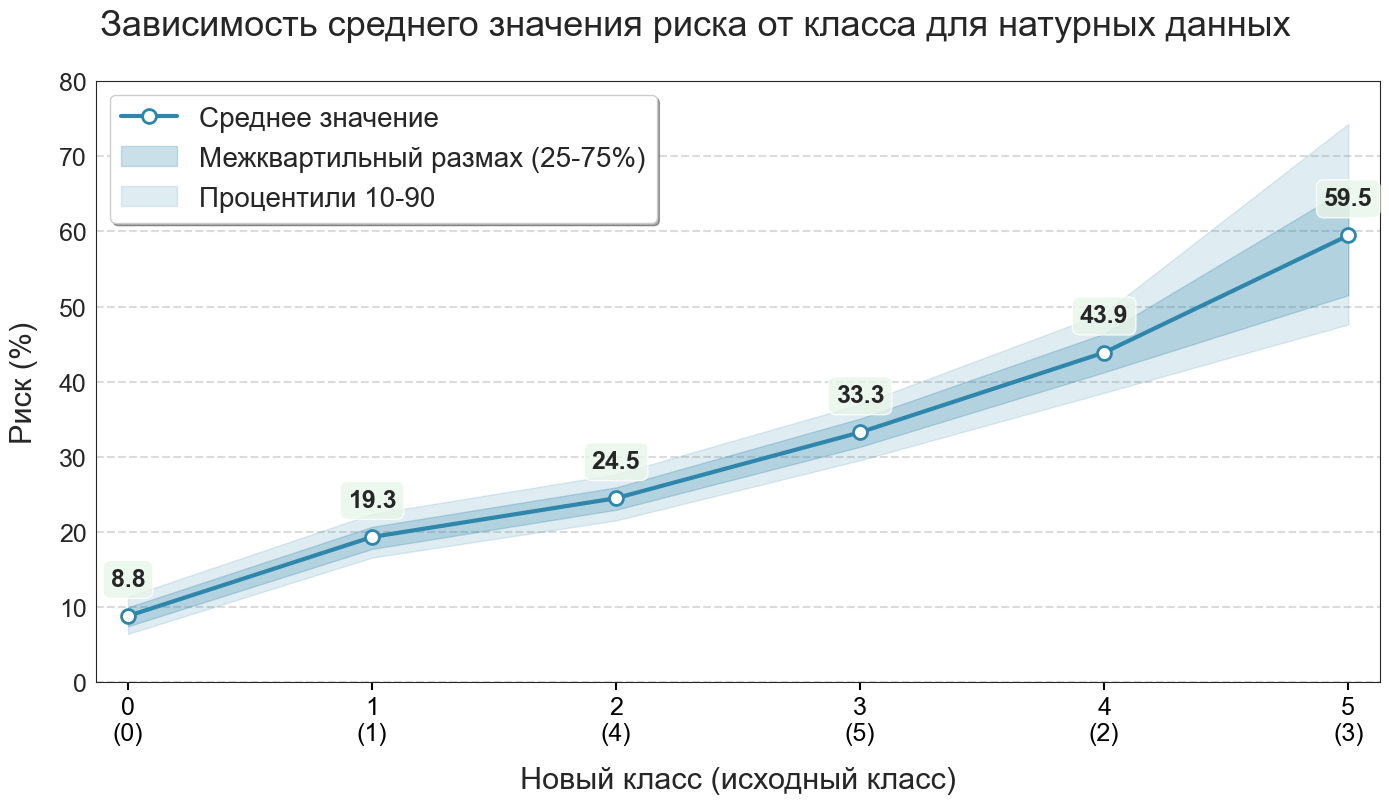

In [9]:
# ==================== ГРАФИК 3: Монотонность среднего риска (улучшенный) ====================
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

sns.set_style("white")
sns.set_palette("husl")

new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend([f'{new_class}'] * sum(y_mapped == new_class))

    
fig = plt.figure(figsize=(14, 8))

plt.tick_params(
    axis='x',        # Обе оси
    which='both',       # Основные и второстепенные
    direction='out',    # Насечки наружу
    length=6,           # Длина насечки
    width=1.5,          # Толщина насечки
    colors='black',     # Цвет насечек
    labelsize=18,       # Размер подписей
    bottom=True,        # Нижние насечки
    left=True,          # Левые насечки
    top=False,          # Без верхних
    right=False         # Без правых
)

# Расчет статистик
means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
medians = [np.median(risk_all[y_mapped == c]) for c in range(n_classes)]
q25 = [np.percentile(risk_all[y_mapped == c], 25) for c in range(n_classes)]
q75 = [np.percentile(risk_all[y_mapped == c], 75) for c in range(n_classes)]
q10 = [np.percentile(risk_all[y_mapped == c], 10) for c in range(n_classes)]
q90 = [np.percentile(risk_all[y_mapped == c], 90) for c in range(n_classes)]

# Основная линия с маркерами
plt.plot(new_classes, means, 'o-', linewidth=3, markersize=10, 
         color='#2E86AB', label='Среднее значение', markerfacecolor='white', 
         markeredgewidth=2, markeredgecolor='#2E86AB')

# Закрашенная область межквартильного размаха (25-75 процентили)
plt.fill_between(new_classes, q25, q75, alpha=0.25, color='#2E86AB', 
                  label='Межквартильный размах (25-75%)')

# Дополнительная область для 10-90 процентилей (более светлая)
plt.fill_between(new_classes, q10, q90, alpha=0.15, color='#2E86AB', 
                  label='Процентили 10-90')

# Добавляем аннотации с значениями
for i, (mean_val, median_val) in enumerate(zip(means, medians)):
    plt.annotate(f'{mean_val:.1f}', 
                 xy=(i, mean_val), 
                 xytext=(i, mean_val + 4),
                 ha='center', 
                 fontsize=18, 
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', alpha=0.8))

plt.xticks(new_classes, old_labels, fontsize=14, fontweight='medium')

# Улучшенные метки и заголовок
plt.xlabel('Новый класс (исходный класс)', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)

fig.suptitle('Зависимость среднего значения риска от класса для натурных данных', 
             fontsize=26, y=1, fontweight='medium')



# Легенда с улучшенным стилем
plt.legend(loc='upper left', fontsize=20, frameon=True, shadow=True)

plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 10))
plt.xlim(-0.13, 5.13)


# Улучшенная сетка

plt.grid(alpha=0.7, axis='y', linestyle='--', linewidth=1.5)  # Оставляем только горизонтальные

plt.tight_layout()
plt.savefig('risk_monotonicity_improved.png', dpi=600, bbox_inches='tight')
plt.show()

## 4 Графика с различными значениями ALPHA

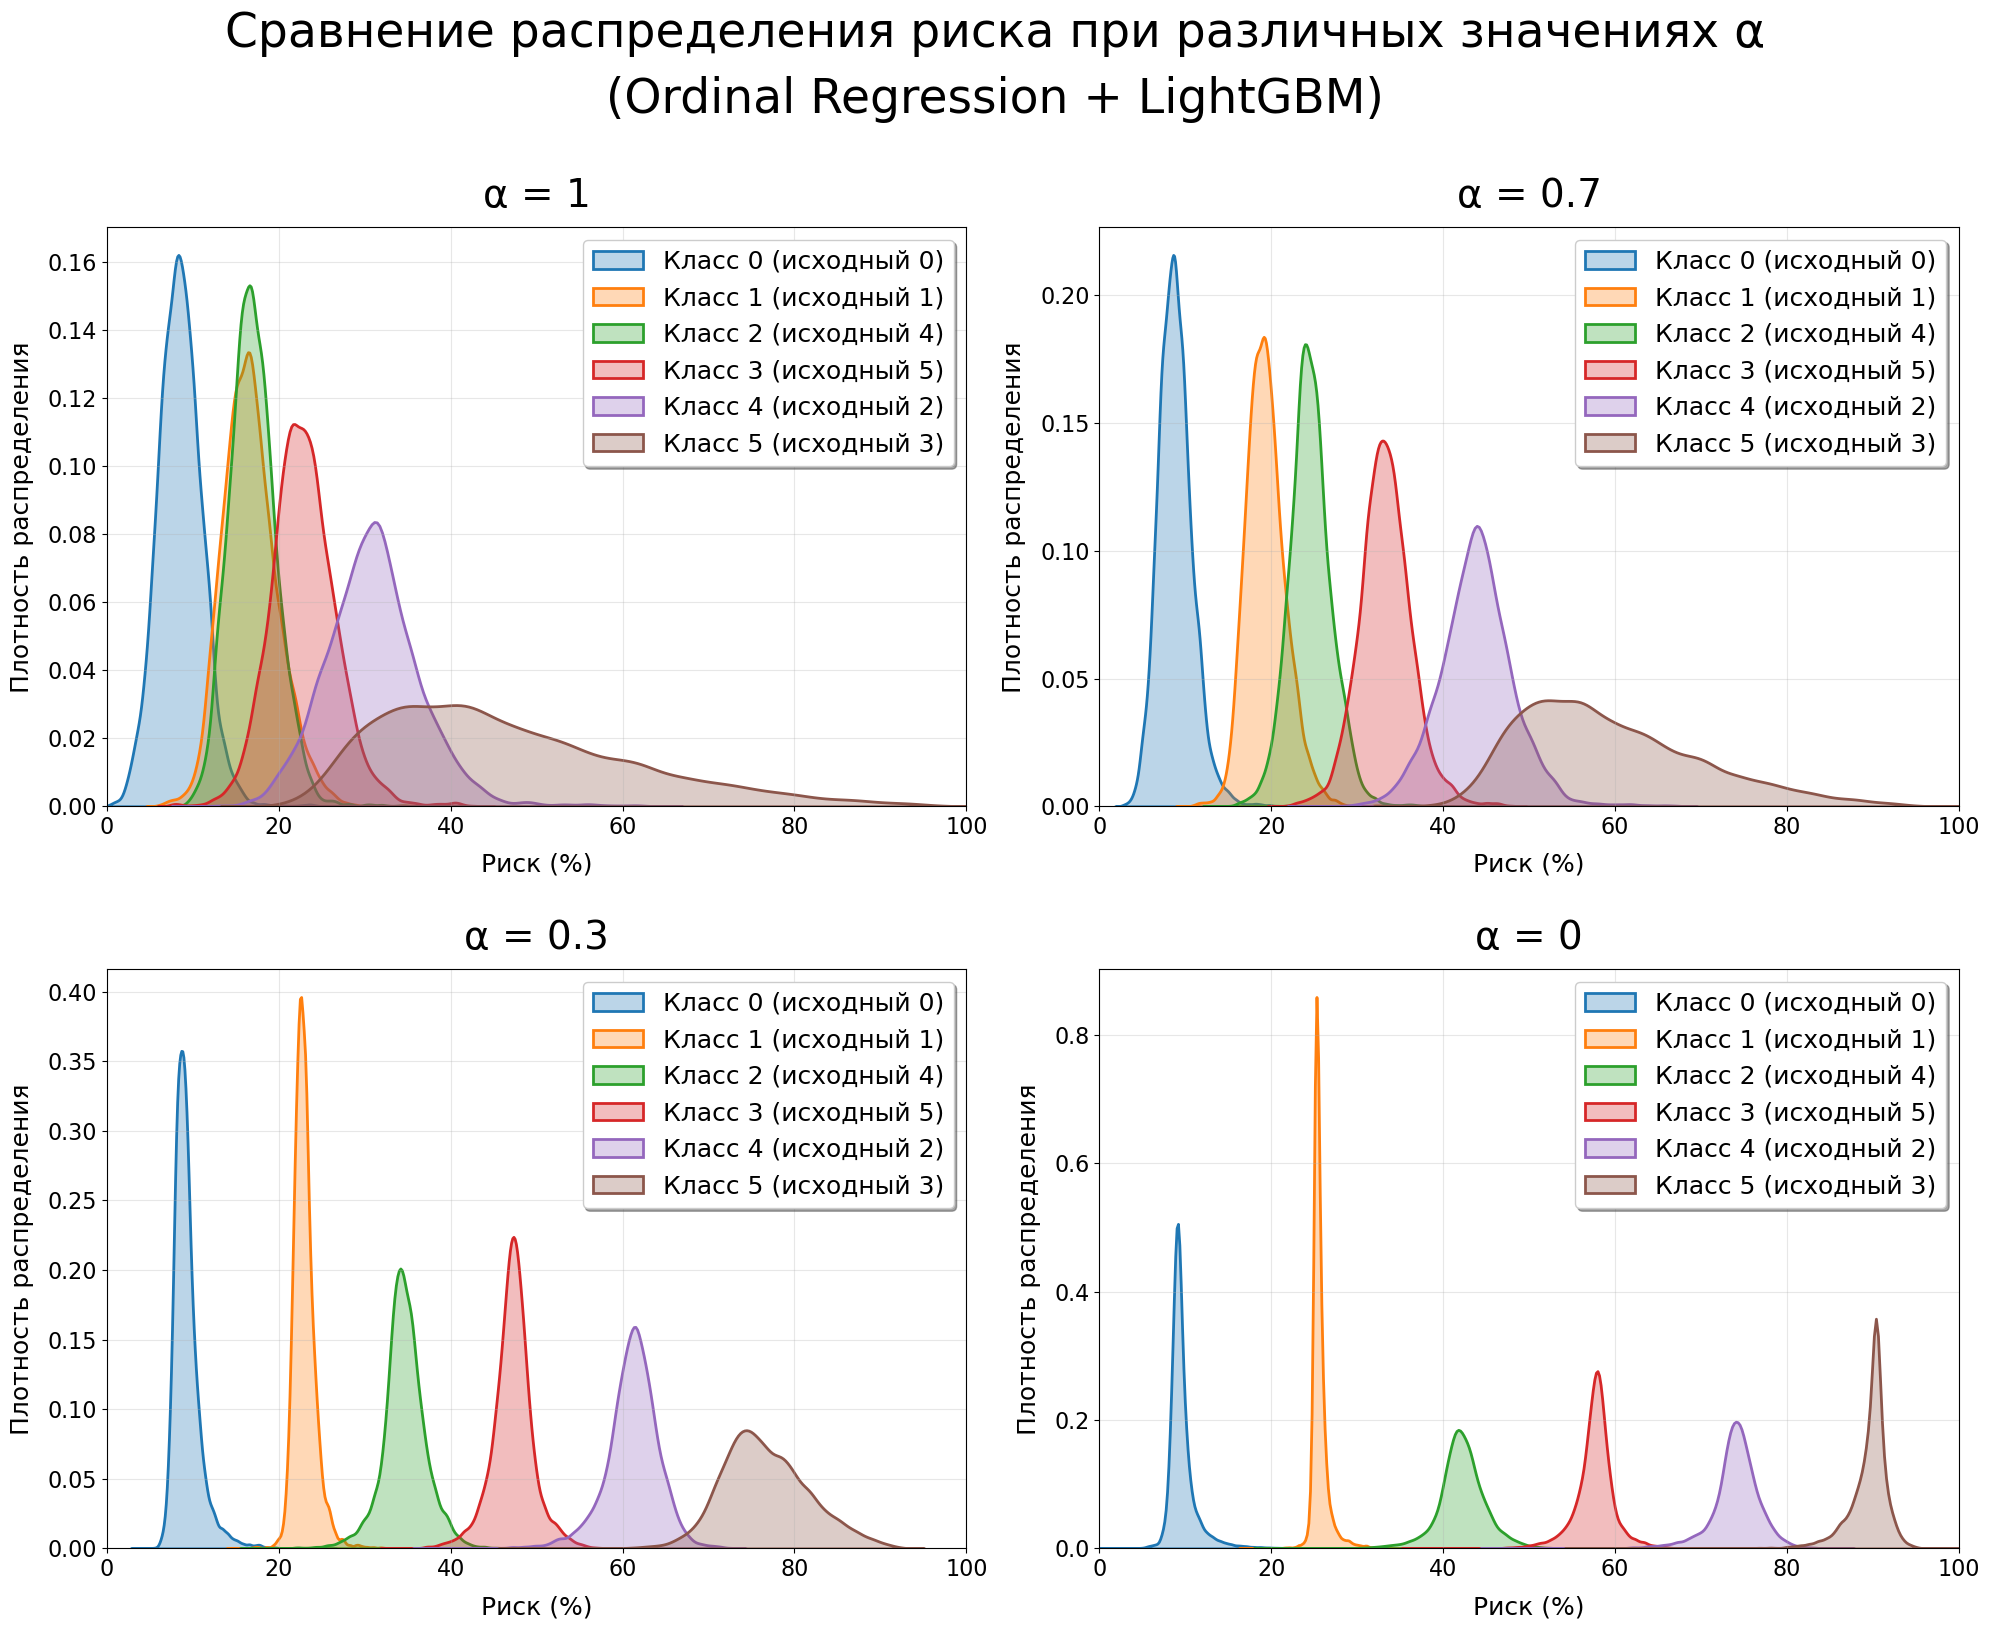


Сравнение коэффициентов Spearman для разных ALPHA:
ALPHA = 1.0: Spearman = 0.9019, p-value = 0.0000e+00
ALPHA = 0.7: Spearman = 0.9743, p-value = 0.0000e+00
ALPHA = 0.3: Spearman = 0.9841, p-value = 0.0000e+00
ALPHA = 0.0: Spearman = 0.9844, p-value = 0.0000e+00


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# Значения ALPHA для тестирования
alpha_values = [1, 0.7, 0.3, 0]

# Создаем полотно 2x2
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()  # Упрощаем индексацию

# Сохраняем результаты для каждого ALPHA
results = []

for idx, ALPHA in enumerate(alpha_values):
    # =========================================================
    # HYBRID 
    # =========================================================
    risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
    risk_all = np.clip(risk_all, 0, 100)
    
    spearman_corr, p_value = spearmanr(risk_all, y_mapped)
    results.append({'alpha': ALPHA, 'spearman': spearman_corr, 'p_value': p_value})
    
    # ==================== ГРАФИК на соответствующей оси ====================
    for new_class in range(n_classes):
        data = risk_all[y_mapped == new_class]
        old_class = inverse_mapping[new_class]
        
        sns.kdeplot(
            data,
            label=f'Класс {new_class} (исходный {fixed_perm[new_class]})',
            fill=True,
            alpha=0.3,
            linewidth=2,
            ax=axes[idx]
        )
    
    axes[idx].set_xlabel("Риск (%)", fontsize=18, fontweight='medium', labelpad=10)
    axes[idx].set_ylabel("Плотность распределения", fontsize=18, fontweight='medium', labelpad=10)
    axes[idx].set_title(f"α = {ALPHA}", 
                        fontsize=28, fontweight='medium', pad=15)
    axes[idx].legend(loc='upper right', fontsize=18, frameon=True, shadow=True)
    axes[idx].grid(alpha=0.3)
    axes[idx].tick_params(axis='x', labelsize=16)
    axes[idx].tick_params(axis='y', labelsize=16)
    axes[idx].set_xlim(0, 100)  # Фиксируем границы для сравнения

# Общий заголовок для всего полотна
fig.suptitle("Сравнение распределения риска при различных значениях α\n(Ordinal Regression + LightGBM)", 
             fontsize=34, fontweight='medium', y=1.015, linespacing=1.5)

plt.tight_layout(h_pad=3.0)

# Сохранение
plt.savefig('risk_distribution_comparison_alpha.png', dpi=600, bbox_inches='tight')
plt.show()

# Вывод статистики
print("\n" + "="*60)
print("Сравнение коэффициентов Spearman для разных ALPHA:")
print("="*60)
for res in results:
    print(f"ALPHA = {res['alpha']:.1f}: Spearman = {res['spearman']:.4f}, p-value = {res['p_value']:.4e}")

# Только ORDINAL

## Поиск лучшей перестановки

In [42]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


NUM_OF_FEATURES = 50
RANDOM_STATE = 42
NOISE_STD = 0.1
ALPHA = 0.7

features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap96.875.csv')

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

n_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

candidates = [
    [0, 1, 4, 5, 2, 3],
    [0, 1, 4, 2, 5, 3],
    [0, 1, 4, 2, 3, 5],
    [0, 1, 2, 3, 4, 5],
    [0, 1, 2, 4, 3, 5],
    [0, 1, 2, 4, 5, 3]
]


def evaluate_permutation(perm):
    
    mapping = {old: new for new, old in enumerate(perm)}
    y_train_m = np.array([mapping[v] for v in y_train])
    y_test_m = np.array([mapping[v] for v in y_test])

    models = []
    for k in range(1, n_classes):
        y_binary = (y_train_m >= k).astype(int)
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
        clf.fit(X_train_scaled, y_binary)
        models.append(clf)

    latent_test = np.mean([m.decision_function(X_test_scaled) for m in models], axis=0)
    spearman, _ = spearmanr(latent_test, y_test_m)
    means = [np.mean(latent_test[y_test_m == c]) for c in range(n_classes)]
    monotonic = all(means[i] < means[i+1] for i in range(n_classes-1))

    return spearman, monotonic, models, mapping


best_spearman = -np.inf
best_models = None
best_mapping = None

for perm in candidates:
    spearman, monotonic, models, mapping = evaluate_permutation(perm)

    if monotonic and spearman > best_spearman:
        best_spearman = spearman
        best_models = models
        best_mapping = mapping

if best_models is None:
    raise ValueError("Ни одна перестановка не дала монотонный порядок.")

print("Spearman:", round(best_spearman, 4))

latent_train = np.mean([m.decision_function(X_train_scaled) for m in best_models], axis=0)

latent_min = latent_train.min()
latent_max = latent_train.max()

# with open(r"DATA/real_time/ordinal_pipeline.pkl", "wb") as f:
#     pickle.dump({
#         "models": best_models,
#         "scaler": scaler,
#         "mapping": best_mapping,
#         "features": selected_features,
#         "latent_min": latent_min,
#         "latent_max": latent_max
#     }, f)


Spearman: 0.9044


Лучшая перестановка: [0, 1, 4, 5, 2, 3]

Статистика Latent Risk по классам:

  Новый класс 0 (исх.0): средний риск = 8.55%
  Новый класс 1 (исх.1): средний риск = 16.55%
  Новый класс 2 (исх.4): средний риск = 17.07%
  Новый класс 3 (исх.5): средний риск = 23.00%
  Новый класс 4 (исх.2): средний риск = 31.23%
  Новый класс 5 (исх.3): средний риск = 47.17%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максисмум
0,0,8.55,2.67,8.47,6.75,10.22,0.49,24.06
1,1,16.55,3.24,16.31,14.32,18.46,5.81,35.72
2,4,17.07,2.79,16.90,15.24,18.74,8.32,34.02
3,5,23.00,3.87,22.84,20.52,25.26,7.51,43.04
4,2,31.23,5.63,31.14,27.64,34.43,9.89,63.95
5,3,47.17,14.72,44.34,35.67,56.22,19.17,96.33


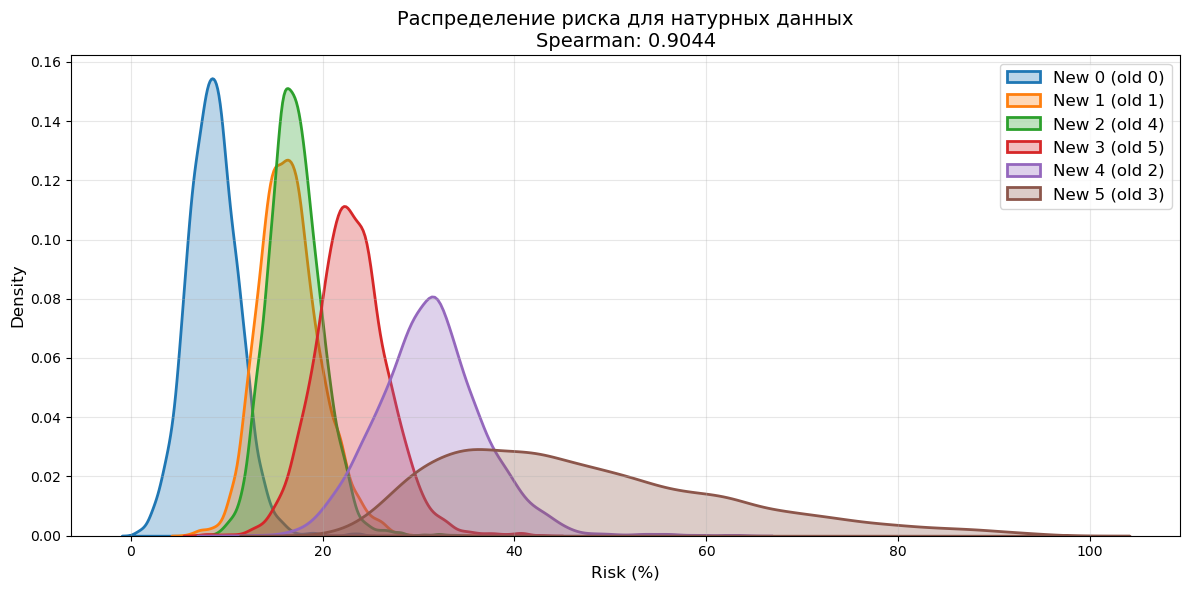

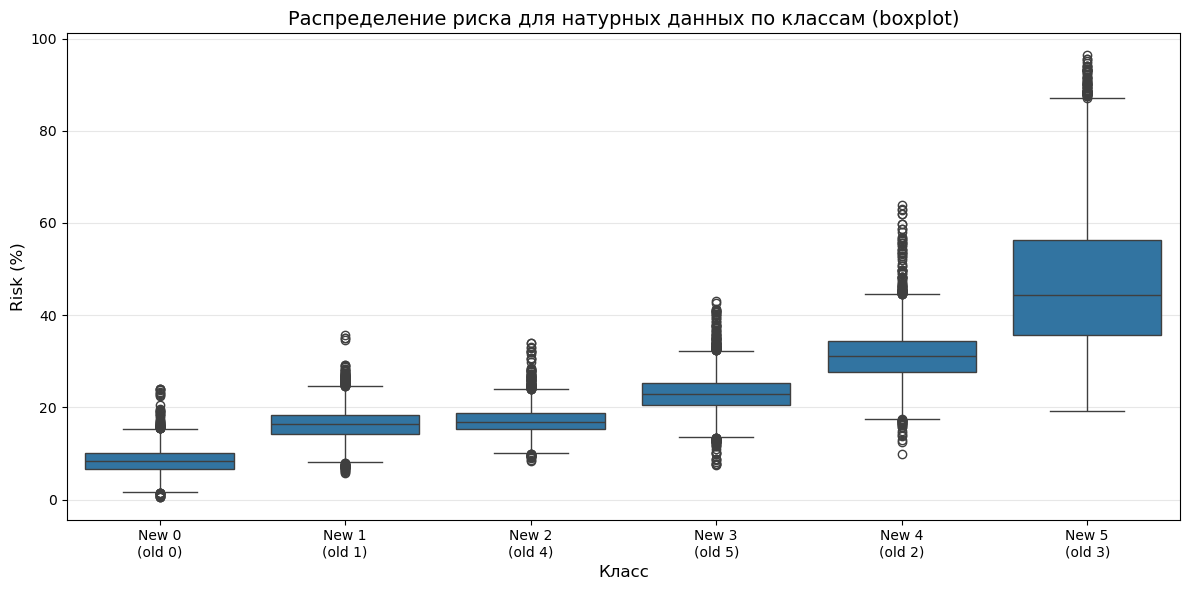

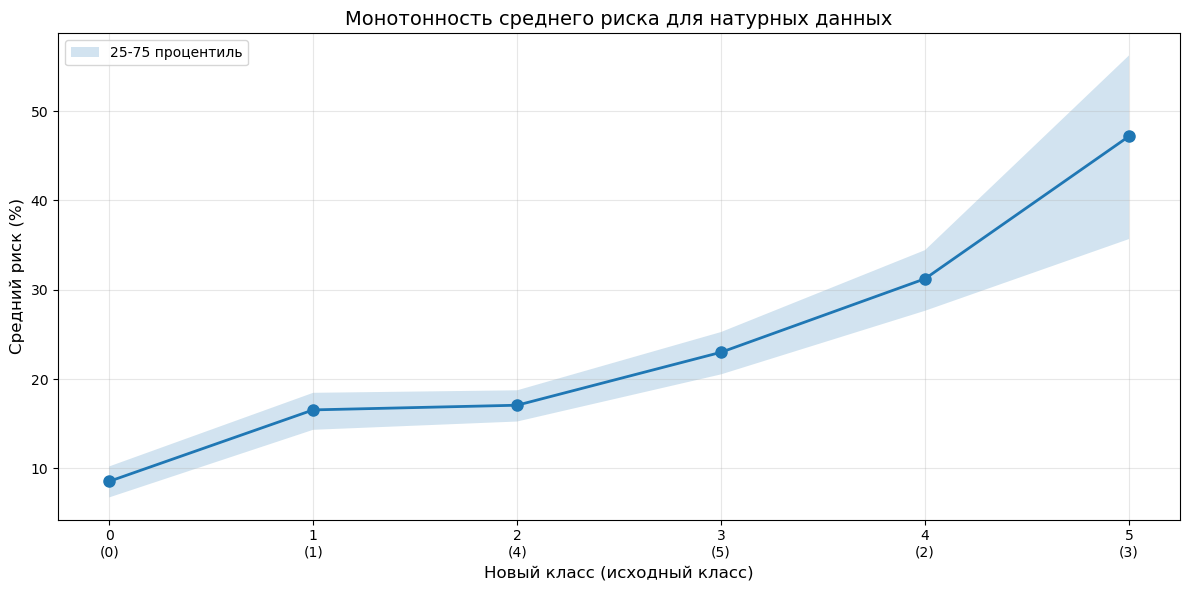

In [43]:
# Преобразуем y_test с помощью best_mapping
best_y_test_m = np.array([best_mapping[v] for v in y_test])

# Вычисляем latent для теста
best_latent = np.mean([m.decision_function(X_test_scaled) for m in best_models], axis=0)

# Приводим к процентной шкале 0-100
risk_latent = 100 * (best_latent - latent_min) / (latent_max - latent_min)
risk_latent = np.clip(risk_latent, 0, 100)

inverse_mapping = {v: k for k, v in best_mapping.items()}
best_perm_list = [inverse_mapping[i] for i in range(n_classes)]
print("Лучшая перестановка:", best_perm_list)

risk_latent = 100 * (best_latent - latent_min) / (latent_max - latent_min)
risk_latent = np.clip(risk_latent, 0, 100)

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_latent[best_y_test_m == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максисмум': np.max(data)
    })

    print(f"  Новый класс {new_class} (исх.{old_class}): средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")

display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максисмум': '{:.2f}'
}))

plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_latent[best_y_test_m == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )

plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(f"Распределение риска для натурных данных\nSpearman: {best_spearman:.4f}", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('APPLICATIONS/risk_distribution.png', dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_latent[best_y_test_m == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'New {new_class}\n(old {old_class})'] * sum(best_y_test_m == new_class)
    )

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

sns.boxplot(data=df_box, x='Class', y='Risk')

plt.title('Распределение риска для натурных данных по классам (boxplot)', fontsize=14)
plt.ylabel('Risk (%)', fontsize=12)
plt.xlabel('Класс', fontsize=12)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('APPLICATIONS/risk_boxplot.png', dpi=400, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))

means = [np.mean(risk_latent[best_y_test_m == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8)
plt.fill_between(
    new_classes,
    [np.percentile(risk_latent[best_y_test_m == c], 25) for c in new_classes],
    [np.percentile(risk_latent[best_y_test_m == c], 75) for c in new_classes],
    alpha=0.2,
    label='25-75 процентиль'
)

plt.xticks(new_classes, old_labels)
plt.xlabel('Новый класс (исходный класс)', fontsize=12)
plt.ylabel('Средний риск (%)', fontsize=12)
plt.title('Монотонность среднего риска для натурных данных', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('APPLICATIONS/risk_monotonicity.png', dpi=400, bbox_inches='tight')
plt.show()

## Итоговое обучение модели на всех данных

Spearman correlation: 0.9019, p-value: 0.0000e+00


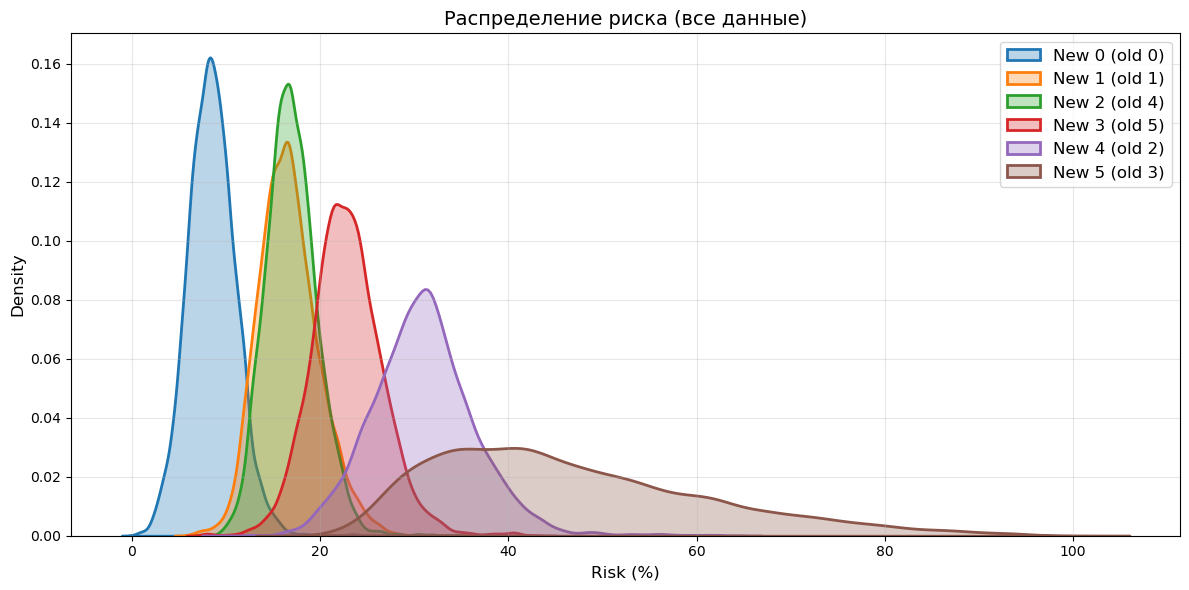

In [44]:
# Итоговое обучение модели на всех данных

import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 50
RANDOM_STATE = 42

# ==================== ДАННЫЕ ====================
features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap96.875.csv')

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

n_classes = len(np.unique(y))

# ==================== МАСШТАБИРОВАНИЕ ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================== ФИКСИРОВАННАЯ ПЕРЕСТАНОВКА ====================
fixed_perm = best_perm_list
fixed_perm = [0, 1, 4, 5, 2, 3]
mapping = {old: new for new, old in enumerate(fixed_perm)}
y_mapped = np.array([mapping[v] for v in y])

# ==================== ОБУЧЕНИЕ БИНАРНЫХ КЛАССИФИКАТОРОВ ====================
models = []
for k in range(1, n_classes):
    y_binary = (y_mapped >= k).astype(int)
    clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    clf.fit(X_scaled, y_binary)
    models.append(clf)

# ==================== ВЫЧИСЛЕНИЕ LATENT ====================
latent_all = np.mean([m.decision_function(X_scaled) for m in models], axis=0)

# === Спирмен ===
spearman_corr, p_value = spearmanr(latent_all, y_mapped)
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {p_value:.4e}")

# ==================== НОРМАЛИЗАЦИЯ В 0-100 ====================
latent_min = latent_all.min()
latent_max = latent_all.max()

risk_latent = 100 * (latent_all - latent_min) / (latent_max - latent_min)
risk_latent = np.clip(risk_latent, 0, 100)

inverse_mapping = {v: k for k, v in mapping.items()}

# ==================== СОХРАНЕНИЕ ПАЙПЛАЙНА ====================
with open(r"DATA/real_time/ordinal_pipeline.pkl", "wb") as f:
    pickle.dump({
        "models": models,
        "scaler": scaler,
        "mapping": mapping,
        "features": selected_features,
        "latent_min": latent_min,
        "latent_max": latent_max
    }, f)

# ==================== ГРАФИК РАСПРЕДЕЛЕНИЯ РИСКА ====================
plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_latent[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )

plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(f"Распределение риска (все данные)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('APPLICATIONS/risk_distribution_all.png', dpi=400, bbox_inches='tight')
plt.show()